# Подготовка модели распознавания рукописных букв и цифр

Вам предстоит самостоятельно обучить модель для задачи распознавания рукописных букв и цифр с помощью датасета `emnist`. Результатом должна быть обученная модель, сохранённая в файл `model.pkl`.

Можете воспользоваться предложенным порядком действий и подсказками из этого ноутбука или подойти к решению задачи самостоятельно и написать всё с нуля. То же касается и процесса упаковки модели в сервис для распознавания самостоятельно написанных символов.

В этом ноутбуке комментариями и символами `...` отмечены места для вашего кода.

Перед отправкой решения убедитесь, что все ячейки ноутбука выполняются последовательно без ошибок, если запустить `Kernel -> Restart & Run All`.

Успехов!

### 1. Установите и импортируйте необходимые библиотеки

In [26]:
import warnings
warnings.filterwarnings("ignore")
import os
import pickle
import gzip
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

### 2. Загрузите датасет и проанализируйте его

Датасет в качестве лейблов (или таргетов) содержит числа от 0 до 46. Каждому числу соответствует ASCII-код некоторого символа. Пары «лейбл — код» хранятся в файле `emnist-balanced-mapping.txt`.
Выведите на экран количество семплов в каждом сплите датасета и размер изображений. Также для каждого лейбла выведите соответствующий ему символ и количество тренировочных семплов, приходящееся на него.
Посмотрите на несколько примеров изображений.

_Подсказка: чтобы получить символ из ASCII-кода, нужно воспользоваться функцией_ `chr()`. _Для вашего удобства можно построить словарь_ (`dict`) _соответствий._

In [27]:

def load_emnist_images(filename):
    with gzip.open(filename, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=16)
    return data.reshape(-1, 28, 28)

def load_emnist_labels(filename):
    with gzip.open(filename, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=8)
    return data

# Загрузка данных из файлов
images_train = load_emnist_images('gzip/emnist-balanced-train-images-idx3-ubyte.gz')
labels_train = load_emnist_labels('gzip/emnist-balanced-train-labels-idx1-ubyte.gz')
images_test = load_emnist_images('gzip/emnist-balanced-test-images-idx3-ubyte.gz')
labels_test = load_emnist_labels('gzip/emnist-balanced-test-labels-idx1-ubyte.gz')

Label distribution:
Label 0 ( ): 2400 samples
Label 1 (): 2400 samples
Label 2 (): 2400 samples
Label 3 (): 2400 samples
Label 4 (): 2400 samples
Label 5 (): 2400 samples
Label 6 (): 2400 samples
Label 7 (): 2400 samples
Label 8 ): 2400 samples
Label 9 (	): 2400 samples
Label 10 (
): 2400 samples
Label 11 (): 2400 samples
Label 12 (): 2400 samples
): 2400 samples
Label 14 (): 2400 samples
Label 15 (): 2400 samples
Label 16 (): 2400 samples
Label 17 (): 2400 samples
Label 18 (): 2400 samples
Label 19 (): 2400 samples
Label 20 (): 2400 samples
Label 21 (): 2400 samples
Label 22 (): 2400 samples
Label 23 (): 2400 samples
Label 24 (): 2400 samples
Label 25 (): 2400 samples
Label 26 (): 2400 samples
Label 27 (): 2400 samples
Label 28 (): 2400 samples
Label 29 (): 2400 samples
Label 30 (): 2400 samples
Label 31 (): 2400 samples
Label 32 ( ): 2400 samples
Label 33 (!): 2400 samples
Label 34 ("): 2400 samples
Label 35 (#): 2400 samples
Label 36 ($): 2400 samples
Labe

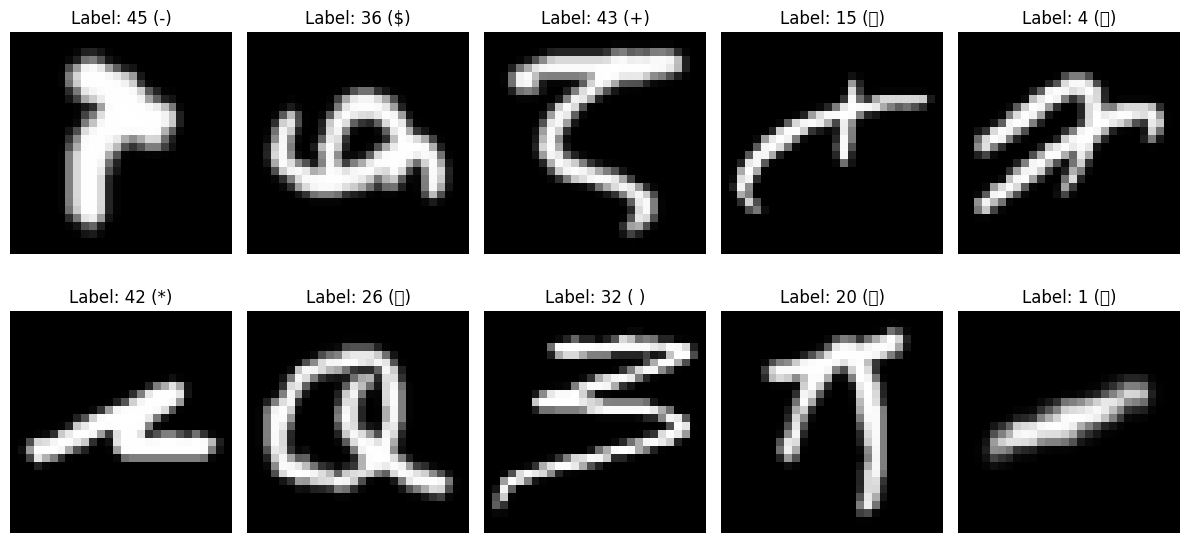

In [28]:
# Загрузка маппинга лейблов в символы
with open('emnist-balanced-mapping.txt', 'r') as f:
    mapping = {int(line.split()[0]): line.split()[1] for line in f.readlines()}

# Анализ распределения классов
unique_labels, counts = np.unique(labels_train, return_counts=True)
print("Label distribution:")
for label, count in zip(unique_labels, counts):
    char = chr(label)
    print(f'Label {label} ({char}): {count} samples')

# Вывод примеров изображений
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(images_train[i], cmap='gray')
    ax.set_title(f'Label: {labels_train[i]} ({chr(labels_train[i])})')
    ax.axis('off')
plt.tight_layout()
plt.show()

### 3. Подготовьте датасет для обучения и валидации

_Подсказка: чтобы вытянуть изображения в вектор, понадобится метод_ `reshape` _из библиотеки_ `numpy`.

In [29]:
# Преобразование изображений в векторы
X_train = images_train.reshape(images_train.shape[0], -1) / 255.0
y_train = labels_train
X_test = images_test.reshape(images_test.shape[0], -1) / 255.0
y_test = labels_test

print('Train:', X_train.shape)
print('Test:', X_test.shape)

Train: (112800, 784)
Test: (18800, 784)


### 4. Выберите модель, обучите её, протестируйте и сохраните

Выведите на экран точность вашей модели. Выведите и проанализируйте матрицу ошибок. Какие два символа она чаще всего путает? На каком символе модель чаще всего ошибается?

Сравнение моделей с использованием кросс-валидации:
Random Forest: 0.8029 (±0.0006)
SVM: 0.8119 (±0.0011)

Лучшая модель: SVM с точностью 0.8119

Обучение лучшей модели (SVM)...
Test accuracy: 0.8209


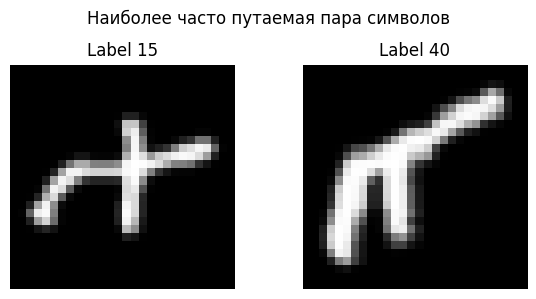

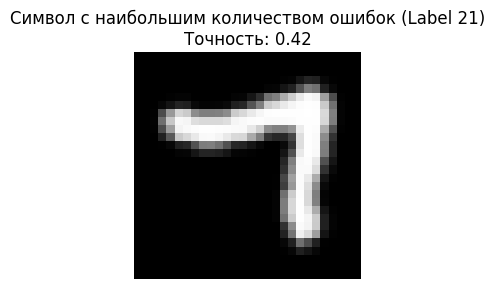


Сохранение лучшей модели (SVM)...


In [30]:
# Определяем модели для сравнения
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=4),
    'SVM': make_pipeline(StandardScaler(), SVC(kernel='rbf', random_state=42)),
}

# Сравниваем модели с помощью кросс-валидации
print("Сравнение моделей с использованием кросс-валидации:")
best_model = None
best_score = 0
best_name = ""

for name, model in models.items():
    # Используем 3-кратную кросс-валидацию
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy')
    mean_score = scores.mean()
    print(f"{name}: {mean_score:.4f} (±{scores.std():.4f})")

    if mean_score > best_score:
        best_score = mean_score
        best_model = model
        best_name = name

print(f"\nЛучшая модель: {best_name} с точностью {best_score:.4f}")

# Обучаем лучшую модель на всех тренировочных данных
print(f"\nОбучение лучшей модели ({best_name})...")
best_model.fit(X_train, y_train)

# Оценка на тестовом наборе
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Test accuracy: {accuracy:.4f}')

# Анализ матрицы ошибок
cm = confusion_matrix(y_test, y_pred)

# Найдем наиболее часто путаемые символы
most_confused = []
for i in range(len(cm)):
    for j in range(len(cm)):
        if i != j:
            most_confused.append((cm[i, j], i, j))

most_confused.sort(reverse=True, key=lambda x: x[0])
top_confusion = most_confused[0]

# Выводим наиболее часто путаемую пару как изображения
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
for idx, (label, ax) in enumerate(zip([top_confusion[1], top_confusion[2]], axes)):
    # Находим первый пример с этим лейблом в тестовом наборе
    img_idx = np.where(y_test == label)[0][0]
    ax.imshow(images_test[img_idx], cmap='gray')
    ax.set_title(f'Label {label}')
    ax.axis('off')
plt.suptitle('Наиболее часто путаемая пара символов')
plt.tight_layout()
plt.show()

# Найдем символ с наибольшим количеством ошибок
errors_per_class = cm.diagonal() / cm.sum(axis=1)
worst_class_idx = np.argmin(errors_per_class)

# Выводим символ с наибольшим количеством ошибок как изображение
plt.figure(figsize=(3, 3))
img_idx = np.where(y_test == worst_class_idx)[0][0]
plt.imshow(images_test[img_idx], cmap='gray')
plt.title(f'Символ с наибольшим количеством ошибок (Label {worst_class_idx})\nТочность: {errors_per_class[worst_class_idx]:.2f}')
plt.axis('off')
plt.tight_layout()
plt.show()

# Сохраняем лучшую модель
print(f"\nСохранение лучшей модели ({best_name})...")

with open(os.path.join('myapp', 'model.pkl'),'wb') as f:
    pickle.dump(best_model, f)